# 3. Análisis extra

Ejecutar después del notebook anterior, con el kernel del `.venv`. La primera celda de código fija la raíz del proyecto y la siguiente carga los datos preparados por la etapa anterior. Reiniciar el kernel y ejecutar todas las celdas para repetir esta etapa.
Los gráficos se guardan también como PNG en `output/graficos/03_analisis_extra/`. Silhouette de DBSCAN se genera únicamente cuando hay al menos dos grupos válidos después de excluir el ruido.


In [1]:
import os
from pathlib import Path

# Permite ejecutar el notebook desde la raíz del proyecto o desde src/.
_directorio = Path.cwd()
if _directorio.name == "src" and (_directorio.parent / "pyproject.toml").is_file():
    os.chdir(_directorio.parent)
elif not (_directorio / "pyproject.toml").is_file():
    raise RuntimeError("Abrí el proyecto desde su raíz o desde src/ antes de ejecutar el notebook.")

In [2]:
import pandas as pd

_estado = pd.read_pickle("output/notebooks/analisis_preliminar.pkl")
alumnos_s_avanzados = _estado["alumnos_s_avanzados"]
alumnos_s_avanzados_sc = _estado["alumnos_s_avanzados_sc"]
alumnos_s_avanzados_dist_mat = _estado["alumnos_s_avanzados_dist_mat"]


## Importaciones y estadístico Hopkins

In [3]:
"""Análisis adicional sobre las variables creadas por el análisis preliminar.

Al igual que el script de R, se ejecuta después de
``script_analisis_preliminar_2025.py`` en el mismo espacio de nombres.
"""


import kmedoids
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.spatial.distance import squareform
from sklearn.cluster import DBSCAN, KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import silhouette_samples
from sklearn.neighbors import NearestNeighbors


def hopkins(data, *, random_state=None):
    """Estadístico Hopkins con los valores por defecto de hopkins::hopkins.

    El R original lo calcula antes de fijar la semilla, por lo que el valor
    puntual cambia entre corridas aunque se conserve el mismo método.
    """
    values = np.asarray(data, dtype=float)
    n, d = values.shape
    m = int(np.ceil(n / 10))
    rng = np.random.default_rng(random_state)
    uniform = rng.uniform(values.min(axis=0), values.max(axis=0), size=(m, d))
    sample_idx = rng.choice(n, size=m, replace=False)
    tree = cKDTree(values)
    # La primera distancia de un dato muestreado es a sí mismo; R la excluye.
    observed = tree.query(values[sample_idx], k=2)[0][:, 1]
    artificial = tree.query(uniform, k=1)[0]
    return float(np.sum(artificial**d) / np.sum(artificial**d + observed**d))


datos_extra = alumnos_s_avanzados_sc.to_numpy(dtype=float)
hopkins_stat = hopkins(datos_extra)
print("Hopkins:", hopkins_stat)

# Exportar también los gráficos que se muestran en Jupyter.
_directorio_graficos = Path("output/graficos/03_analisis_extra")
_directorio_graficos.mkdir(parents=True, exist_ok=True)


def _guardar_grafico(figura, nombre):
    figura.savefig(
        _directorio_graficos / f"{nombre}.png", dpi=160, bbox_inches="tight"
    )


Hopkins: 0.9999768048124468


## K-means con cuatro grupos

In [4]:
# R usa 25 inicios aleatorios y fija la semilla antes de cada valor de k.
# Hartigan-Wong (R) y Lloyd (scikit-learn) pueden alcanzar óptimos distintos.
kmeans_model = KMeans(
    n_clusters=4, init="random", n_init=25, random_state=123, algorithm="lloyd"
).fit(datos_extra)
alumnos_s_avanzados["cluster_kmeans"] = pd.Categorical(kmeans_model.labels_ + 1)


## DBSCAN y distancias a vecinos

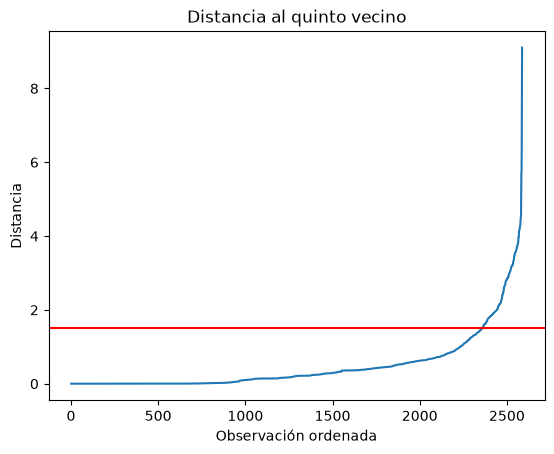

In [5]:
# Distancia al quinto vecino, excluido el propio punto.
vecinos = NearestNeighbors(n_neighbors=6).fit(datos_extra)
distancias_vecinos = np.sort(vecinos.kneighbors(datos_extra)[0][:, 5])
fig_vecinos, ax_vecinos = plt.subplots()
ax_vecinos.plot(np.arange(1, len(distancias_vecinos) + 1), distancias_vecinos)
ax_vecinos.axhline(1.5, color="red")
ax_vecinos.set(
    title="Distancia al quinto vecino",
    xlabel="Observación ordenada",
    ylabel="Distancia",
)

db_model = DBSCAN(eps=1.5, min_samples=5).fit(datos_extra)
alumnos_s_avanzados["cluster_dbscan"] = pd.Categorical(db_model.labels_ + 1)

_guardar_grafico(fig_vecinos, "distancia_quinto_vecino")


## Validación de K-means y DBSCAN con Silhouette

Silhouette DBSCAN no disponible: 1 grupos y 2393 observaciones sin ruido; se requieren entre 2 y n - 1 grupos. Continúa el análisis.


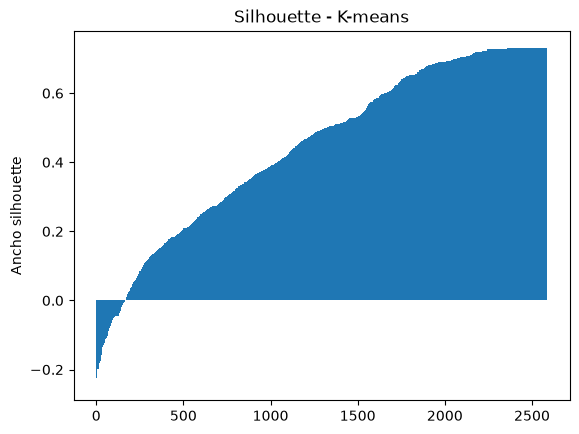

In [6]:
sil_k = silhouette_samples(datos_extra, kmeans_model.labels_)
fig_kmeans, ax_kmeans = plt.subplots()
ax_kmeans.bar(np.arange(len(sil_k)), np.sort(sil_k), width=1)
ax_kmeans.set(title="Silhouette - K-means", ylabel="Ancho silhouette")
_guardar_grafico(fig_kmeans, "silhouette_kmeans")

dbscan_valid_idx = np.flatnonzero(db_model.labels_ != -1)
_etiquetas_dbscan = db_model.labels_[dbscan_valid_idx]
_cantidad_grupos_dbscan = len(np.unique(_etiquetas_dbscan))
sil_d = None
if 2 <= _cantidad_grupos_dbscan < len(dbscan_valid_idx):
    sil_d = silhouette_samples(
        datos_extra[dbscan_valid_idx], _etiquetas_dbscan
    )
    fig_dbscan, ax_dbscan = plt.subplots()
    ax_dbscan.bar(np.arange(len(sil_d)), np.sort(sil_d), width=1)
    ax_dbscan.set(title="Silhouette - DBSCAN", ylabel="Ancho silhouette")
    _guardar_grafico(fig_dbscan, "silhouette_dbscan")
else:
    # Evitar que una imagen de una ejecución anterior parezca un resultado actual.
    (_directorio_graficos / "silhouette_dbscan.png").unlink(missing_ok=True)
    print(
        "Silhouette DBSCAN no disponible:",
        _cantidad_grupos_dbscan,
        "grupos y", len(dbscan_valid_idx), "observaciones sin ruido;",
        "se requieren entre 2 y n - 1 grupos. Continúa el análisis."
    )


## Comparación de K-means, PAM y DBSCAN

In [7]:
kmeans_res = KMeans(
    n_clusters=7, init="random", n_init=25, random_state=123, algorithm="lloyd"
).fit(datos_extra)
sil_kmeans = silhouette_samples(datos_extra, kmeans_res.labels_)
print("Silhouette K-means (k=7):", sil_kmeans.mean())

# PAM recibe las distancias euclidianas sin volver a estandarizar los datos.
# La matriz ya fue calculada por el análisis preliminar.
distancias_pam = squareform(alumnos_s_avanzados_dist_mat)
pam_res = kmedoids.KMedoids(
    n_clusters=7, metric="precomputed", method="pam", init="build"
)
pam_res.fit(distancias_pam)
sil_pam = silhouette_samples(distancias_pam, pam_res.labels_, metric="precomputed")
print("Silhouette PAM (k=7):", sil_pam.mean())
if sil_d is not None:
    print("Silhouette DBSCAN:", sil_d.mean())
else:
    print("Silhouette DBSCAN: no disponible para esta partición.")


Silhouette K-means (k=7): 0.37711925706613075


Silhouette PAM (k=7): 0.30949041928635557
Silhouette DBSCAN: no disponible para esta partición.


## Random Forest e importancia de variables

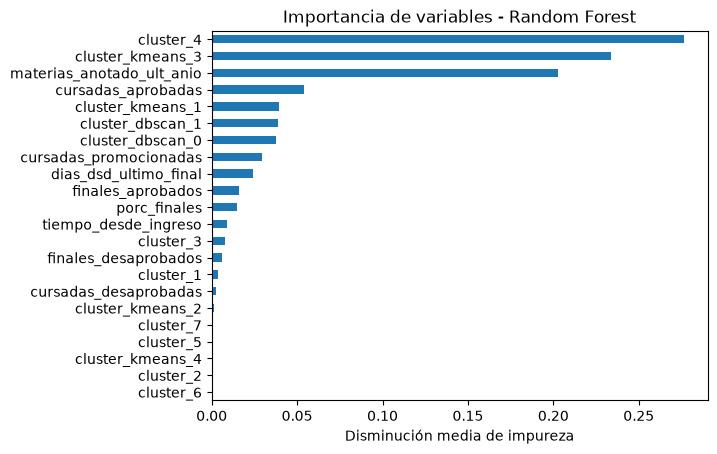

In [8]:
# El bosque usa las mismas 500 muestras bootstrap y mtry=floor(sqrt(p))
# que randomForest para clasificación. Las variables categóricas se codifican
# para scikit-learn; los árboles y el generador aleatorio no son idénticos a R.
predictores_rf = alumnos_s_avanzados.drop(columns="deserto")
predictores_rf = pd.get_dummies(
    predictores_rf, columns=["cluster", "cluster_kmeans", "cluster_dbscan"], dtype=int
)
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=1,
    bootstrap=True,
    oob_score=True,
    random_state=123,
    n_jobs=-1,
).fit(predictores_rf, alumnos_s_avanzados["deserto"].astype(int))
importancia_rf = pd.Series(rf_model.feature_importances_, index=predictores_rf.columns)
fig_rf, ax_rf = plt.subplots()
importancia_rf.sort_values().plot.barh(ax=ax_rf)
ax_rf.set(
    title="Importancia de variables - Random Forest",
    xlabel="Disminución media de impureza",
)

_guardar_grafico(fig_rf, "importancia_random_forest")

plt.show()
